In [11]:
import pandas as pd
import math
import numpy as np
import matplotlib.pyplot as plt

In [12]:
### load provided hg38 wgs intervals
interval_df = pd.read_csv("/home/hain/EMBL/Saturn3/data/intervals/hg38_wgs_intervals.bed", sep="\t", header=None, names=["chr", "start", "end"])
interval_df["length"] = interval_df["end"] - interval_df["start"]

In [25]:
### build new set of smaller intervals

### max interval length
max_interval_length = 50_000_000

### store new intervals here
new_intervals = []

for _, row in interval_df.iterrows():
    if row["length"] > max_interval_length:
        
        ### calculate number of splits
        num_splits = math.ceil(row["length"] / max_interval_length)

        ### make borders
        borders = np.linspace(row["start"], row["end"], num_splits + 1, dtype=int)

        ### create new intervals
        for i in range(num_splits):
            new_intervals.append({"chrom": row["chr"], "start": borders[i], "end": borders[i + 1] - 1})
    else:
        new_intervals.append({"chrom": row["chr"], "start": row["start"], "end": row["end"]})

new_interval_df = pd.DataFrame(new_intervals)
new_interval_df["length"] = new_interval_df["end"] - new_interval_df["start"]

order = ["chr" + str(i) for i in range(1, 23)] + ["chrX", "chrY"]

new_interval_df["chrom"] = pd.Categorical(new_interval_df["chrom"], categories=order, ordered=True)
new_interval_df = new_interval_df.sort_values(["chrom", "start"]).reset_index(drop=True)

In [26]:
new_interval_df[new_interval_df["chrom"] == "chrX"]

,chrom,start,end,length
322,chrX,10000,44821,34821
323,chrX,94821,133871,39050
324,chrX,222346,1949345,1726999
325,chrX,2132994,37099262,34966268
326,chrX,37285837,49348394,12062557
327,chrX,49528394,50228964,700570
328,chrX,50278964,58555579,8276615
329,chrX,58605579,62412542,3806963
330,chrX,62462542,88371869,25909327
331,chrX,88371870,114281197,25909327


In [14]:
new_interval_df[["chrom", "start", "end"]].to_csv("/home/hain/EMBL/Saturn3/data/intervals/hg38_wgs_intervals_50mb.bed", sep="\t", header=False, index=False)

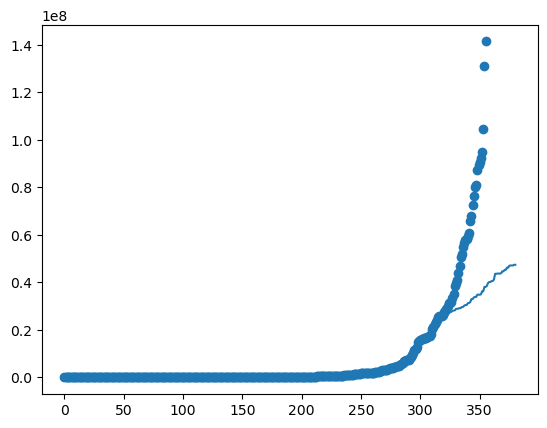

In [34]:
fig, ax = plt.subplots()

ax.scatter(range(interval_df.shape[0]), interval_df.sort_values(by="length")["length"], label="original intervals")
ax.plot(range(new_interval_df.shape[0]), new_interval_df.sort_values(by="length")["length"], label="new intervals")

plt.show()